In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
#Step 1
#load your dataset
df=pd.read_csv('Desktop/DATA TYPES/DIRTY DATA.csv')

#STEP 2; DATA EXPLORATION

In [3]:
df. head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
995,996,5/16/2023,CUST996,Male,62,Clothing,1,50,50
996,997,11/17/2023,CUST997,Male,52,Beauty,3,30,90
997,998,10/29/2023,CUST998,Female,23,Beauty,4,25,100
998,999,12/5/2023,CUST999,Female,36,Electronics,3,50,150
999,1000,4/12/2023,CUST1000,Male,47,Electronics,4,30,120


In [5]:
df.shape

(1000, 9)

In [6]:
df.describe()

,Transaction ID,Age
count,1000.000000,1000.00000
mean,500.500000,41.39200
std,288.819436,13.68143
min,1.000000,18.00000
25%,250.750000,29.00000
50%,500.500000,42.00000
75%,750.250000,53.00000
max,1000.000000,64.00000


In [7]:
df.dropna()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,5/16/2023,CUST996,Male,62,Clothing,1,50,50
996,997,11/17/2023,CUST997,Male,52,Beauty,3,30,90
997,998,10/29/2023,CUST998,Female,23,Beauty,4,25,100
998,999,12/5/2023,CUST999,Female,36,Electronics,3,50,150


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              997 non-null    str  
 2   Customer ID       996 non-null    str  
 3   Gender            999 non-null    str  
 4   Age               1000 non-null   int64
 5   Product Category  997 non-null    str  
 6   Quantity          999 non-null    str  
 7   Price per Unit    999 non-null    str  
 8   Sales             999 non-null    str  
dtypes: int64(2), str(7)
memory usage: 106.0 KB


In [9]:
df['Sales'].unique()

<ArrowStringArray>
[        '150',        '1000',          '30',         '500',         '100',
          '50',         '600',         '200',          '75',        '1500',
 'one hundred',        '2000',         '900',         '120',         '300',
        '1200',          '90',          '25',          '60',           nan]
Length: 20, dtype: str

In [10]:
#step3; check for unstandardize/inconsistent text or numbers

In [11]:
df['Price per Unit'] = pd.to_numeric(df['Price per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors="coerce")
# -Convert Order_Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [12]:
# step 4 check for missing values

df.isnull().sum()

Transaction ID      0
Date                3
Customer ID         4
Gender              1
Age                 0
Product Category    3
Quantity            3
Price per Unit      2
Sales               2
dtype: int64

In [13]:
#Step 5.
#Filling the missing numbers

In [14]:
df['Customer ID'] =df ['Customer ID'].fillna('0')

In [15]:
df['Gender'] =df ['Gender'].fillna('unknown')

In [16]:
df['Product Category'] = df['Product Category'].fillna('unknown')

In [17]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [18]:
df['Price per Unit'] = df['Price per Unit'].fillna(df['Price per Unit'].median())


In [19]:
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

In [20]:
#step 6 confirm if the missing value is filled
df.isnull().sum()

Transaction ID      0
Date                3
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Sales               0
dtype: int64

In [21]:
# step7. check for duplicate numbers
df.duplicated().sum ()


np.int64(0)

In [22]:
df.drop_duplicates()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
0,1,2023-11-24,CUST001,Male,34,Beauty,3.0,50.0,150.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2.0,500.0,1000.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1.0,30.0,30.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1.0,500.0,500.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2.0,50.0,100.0
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1.0,50.0,50.0
996,997,2023-11-17,CUST997,Male,52,Beauty,3.0,30.0,90.0
997,998,2023-10-29,CUST998,Female,23,Beauty,4.0,25.0,100.0
998,999,2023-12-05,CUST999,Female,36,Electronics,3.0,50.0,150.0


In [23]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

In [24]:
df['Gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'MALE', 'unknown', 'FEMALE']
Length: 5, dtype: str

In [25]:
df['Gender'].value_counts()

Gender
Female     510
Male       486
MALE         2
unknown      1
FEMALE       1
Name: count, dtype: int64

In [26]:
df['Gender']=df['Gender'].str.lower()

In [27]:
df['Gender'].value_counts()

Gender
female     511
male       488
unknown      1
Name: count, dtype: int64

In [28]:
df['Quantity'].unique()

array([3., 2., 1., 4.])

In [29]:
df['Price per Unit'].unique()


array([ 50., 500.,  30.,  25., 300.,   0., -30.])

In [30]:
df.loc[df['Price per Unit'] < 0, 'Price per Unit'] = np.nan

In [31]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

In [32]:
df['Sales'] = df['Sales'].replace({'one hundred': 100})


In [33]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

In [34]:
#step 9; confirm if your data type is correct
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              997 non-null    datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   float64       
 7   Price per Unit    999 non-null    float64       
 8   Sales             1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 90.5 KB


In [35]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

#STEP 10;check for Outliers

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

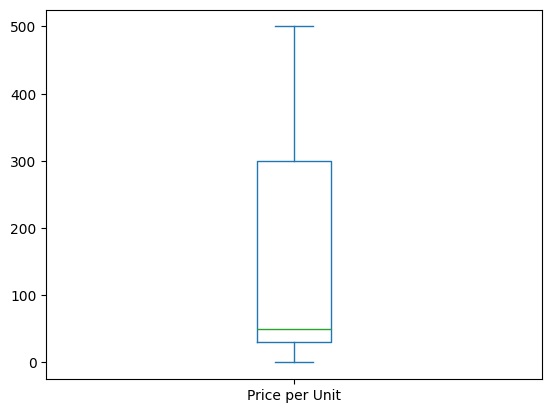

In [37]:
df['Price per Unit'].plot(kind='box')
plt.show()


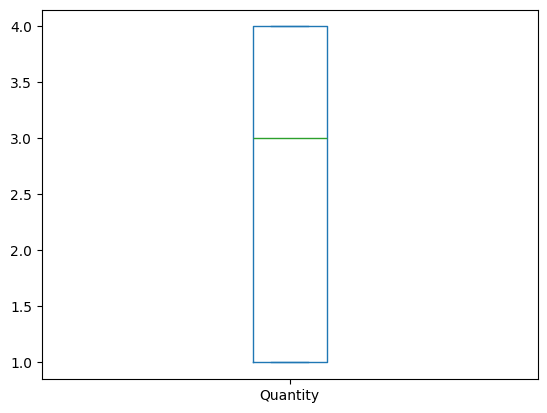

In [38]:
df['Quantity'].plot(kind='box')
plt.show()

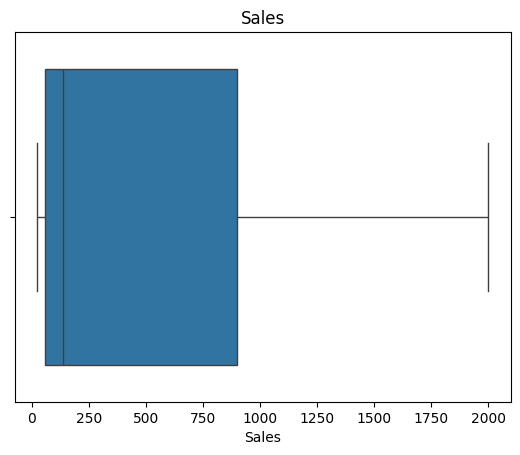

In [39]:
sns.boxplot(x=df['Sales'])
plt.title("Sales")
plt.show()

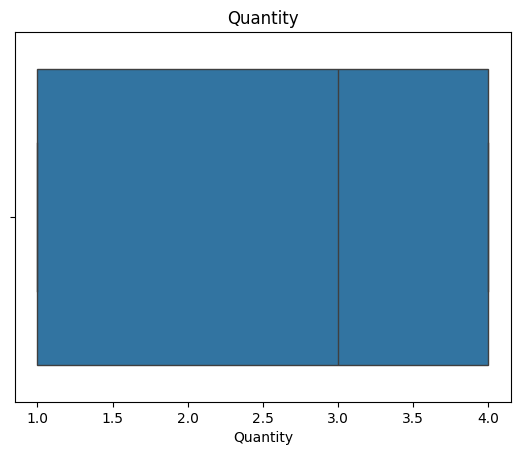

In [40]:
sns.boxplot(x=df['Quantity'])
plt.title("Quantity")
plt.show()

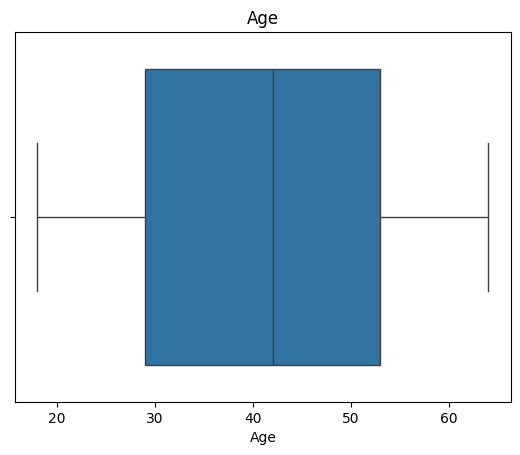

In [41]:
sns.boxplot(x=df['Age'])
plt.title("Age")
plt.show()

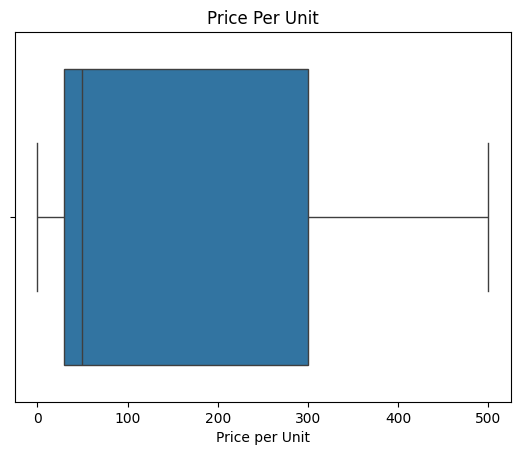

In [42]:
sns.boxplot(x=df['Price per Unit'])
plt.title("Price Per Unit")
plt.show()

In [43]:
# if there is an oulier proceed with this code
cols = ['Age', 'Quantity', 'Price per Unit', 'Sales']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [44]:
df['Sales'] = df['Sales'].clip(lower, upper)

In [45]:
df['Outlier_Flag'] = ((df['Sales'] < lower) | (df['Sales'] > upper))

In [46]:
#Save cleaned data
df.to_csv("cleaned_sales.csv", index=False)
print("Cleaning complete. Saved as cleaned_sales.csv")

Cleaning complete. Saved as cleaned_sales.csv


In [47]:
# Q1 What product category  generate the most revenue?

In [48]:
df['Product Category']

0           Beauty
1         Clothing
2      Electronics
3         Clothing
4           Beauty
          ...     
995       Clothing
996         Beauty
997         Beauty
998    Electronics
999    Electronics
Name: Product Category, Length: 999, dtype: str

In [49]:
df.groupby('Product Category')['Sales'].sum()

Product Category
Beauty         143515.0
Clothing       152240.0
Electronics    155705.0
unknown          3400.0
Name: Sales, dtype: float64

In [50]:
df.groupby('Product Category')['Sales'].sum().sort_values()


Product Category
unknown          3400.0
Beauty         143515.0
Clothing       152240.0
Electronics    155705.0
Name: Sales, dtype: float64

In [51]:
df.groupby('Product Category')["Sales"].sum().reset_index()

,Product Category,Sales
0,Beauty,143515.0
1,Clothing,152240.0
2,Electronics,155705.0
3,unknown,3400.0


In [52]:
df.groupby('Product Category')["Sales"].count().reset_index()

,Product Category,Sales
0,Beauty,307
1,Clothing,348
2,Electronics,341
3,unknown,3


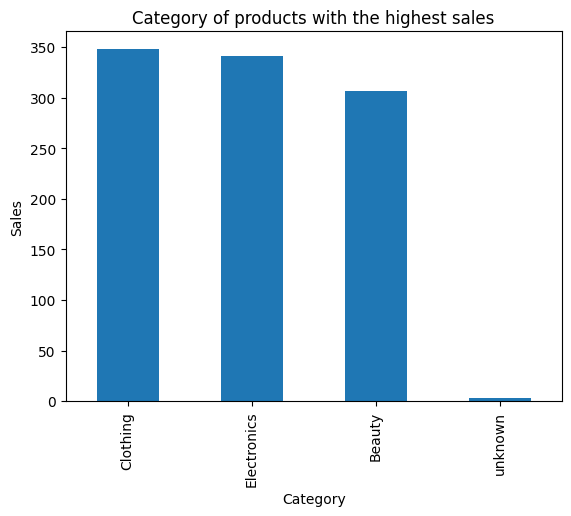

In [53]:
import matplotlib.pyplot as plt
df.groupby("Product Category")["Sales"].count().sort_values(ascending=False).head(100).plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category of products with the highest sales")
plt.show()

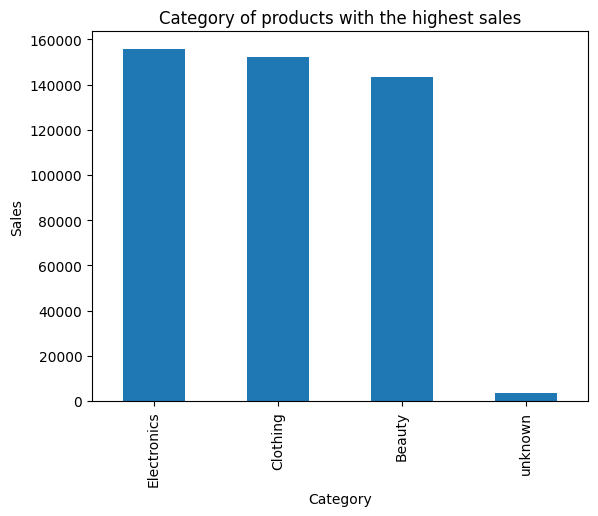

In [54]:
import matplotlib.pyplot as plt
df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False).head(100).plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category of products with the highest sales")
plt.show()

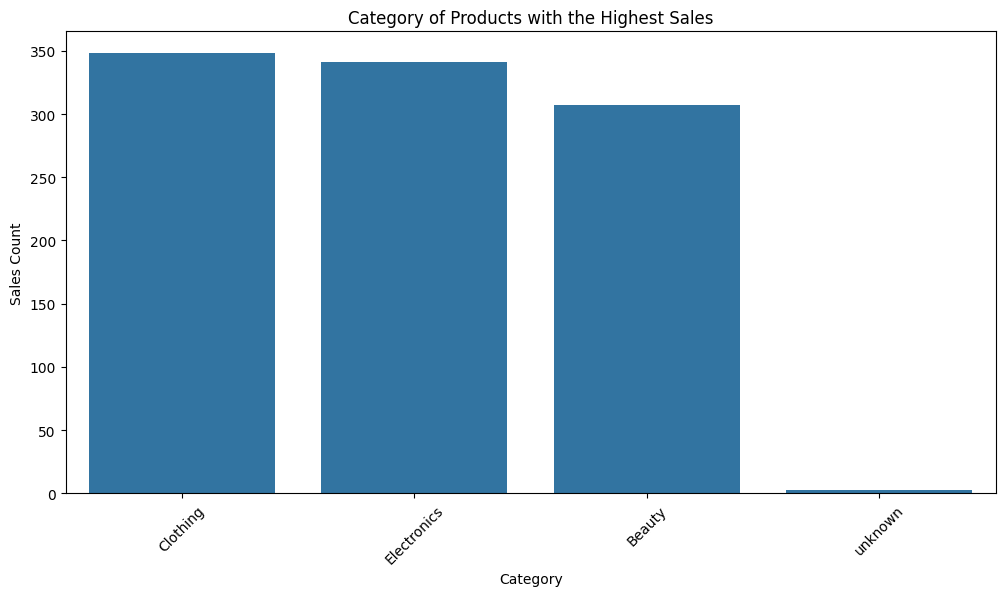

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and prepare data
category_sales = df.groupby("Product Category")["Sales"].count().sort_values(ascending=False).head(100)

# Convert to DataFrame for Seaborn
category_sales = category_sales.reset_index()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=category_sales,
    x="Product Category",
    y="Sales"
)

plt.xlabel("Category")
plt.ylabel("Sales Count")
plt.title("Category of Products with the Highest Sales")
plt.xticks(rotation=45)
plt.show()

In [56]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


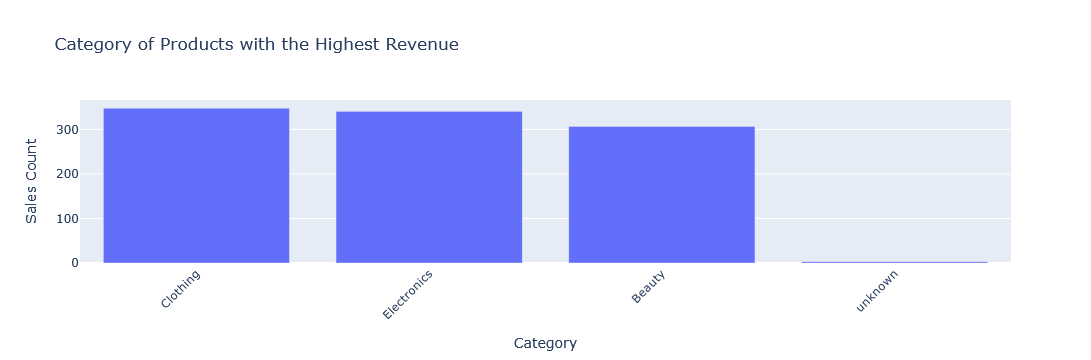

In [57]:
import plotly.express as px

# Group data
category_sales = df.groupby("Product Category")["Sales"].count().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Product Category",
    y="Sales",
    title="Category of Products with the Highest Revenue",
    labels={"Product Category": "Category", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

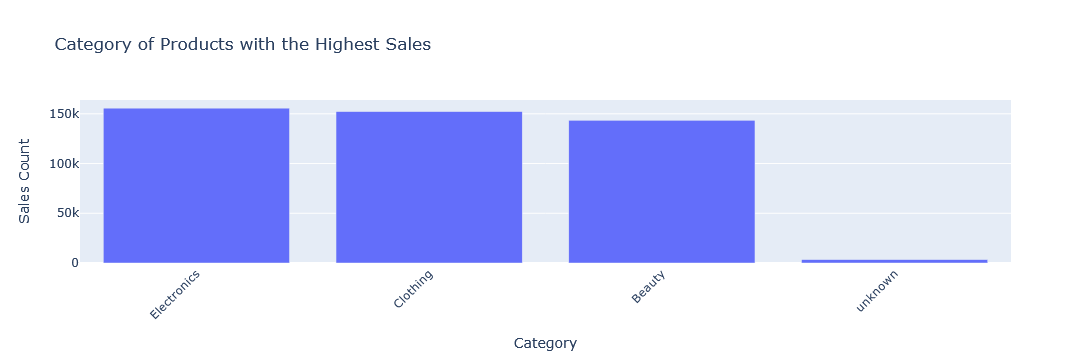

In [58]:
import plotly.express as px

# Group data
category_sales = df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Product Category",
    y="Sales",
    title="Category of Products with the Highest Sales",
    labels={"Product Category": "Category", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [59]:
df.groupby('Product Category')['Sales'].sum()

Product Category
Beauty         143515.0
Clothing       152240.0
Electronics    155705.0
unknown          3400.0
Name: Sales, dtype: float64

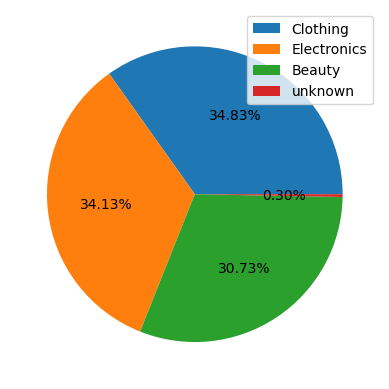

In [60]:
counts = df["Product Category"].value_counts()
plt.pie(counts, autopct="%0.002f%%")
plt.legend(counts.index)
plt.show()

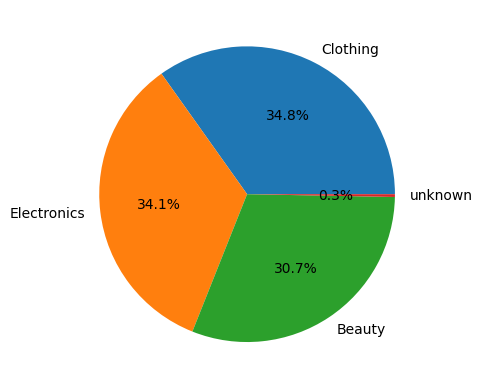

In [61]:
counts = df["Product Category"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.show()

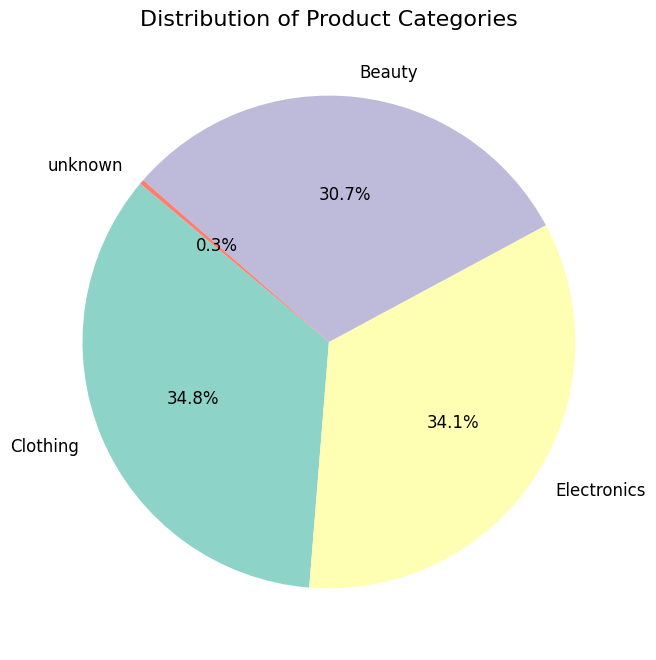

In [62]:
#Product Category Pie Chart 

category_counts = df["Product Category"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=plt.cm.Set3.colors, startangle=140, textprops={'fontsize': 12})
plt.title('Distribution of Product Categories', fontsize=16)
plt.show()

In [63]:
#2Who are the most valuable customers? 

In [64]:
df.groupby('Customer ID')['Sales'].sum().reset_index()

,Customer ID,Sales
0,0,780.0
1,CUST001,150.0
2,CUST002,1000.0
3,CUST003,30.0
4,CUST004,500.0
...,...,...
991,CUST995,30.0
992,CUST996,50.0
993,CUST997,90.0
994,CUST998,100.0


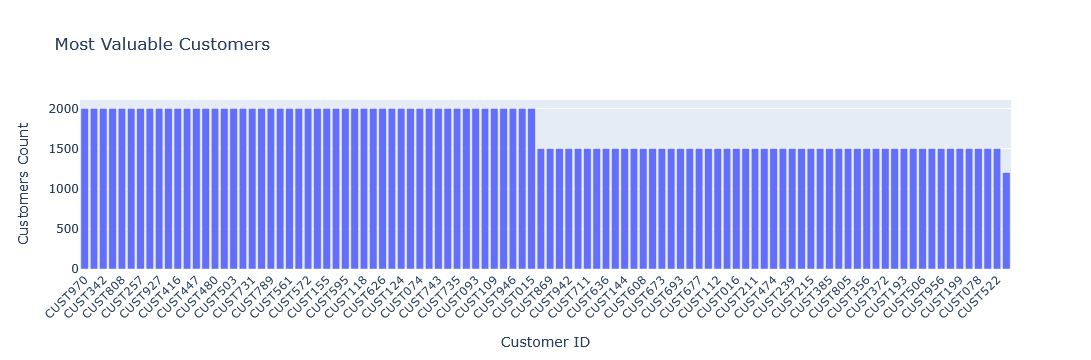

In [65]:
# Group data
category_sales = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Customer ID",
    y="Sales",
    title=" Most Valuable Customers",
    labels={"Customers": "Category", "Sales": "Customers Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [66]:
#3.	What drives sales: quantity or price? 

“The correlation analysis shows that sales have a strong positive relationship with price per unit (0.85), meaning higher-priced products contribute more to revenue. However, quantity has a weaker relationship with sales (0.37), indicating that volume of purchases has less impact. There is almost no relationship between quantity and price, meaning pricing does not significantly influence how much customers buy.

In [67]:
df[["Sales", "Quantity", "Price per Unit"]].corr()

,Sales,Quantity,Price per Unit
Sales,1.000000,0.371887,0.850871
Quantity,0.371887,1.000000,0.019509
Price per Unit,0.850871,0.019509,1.000000


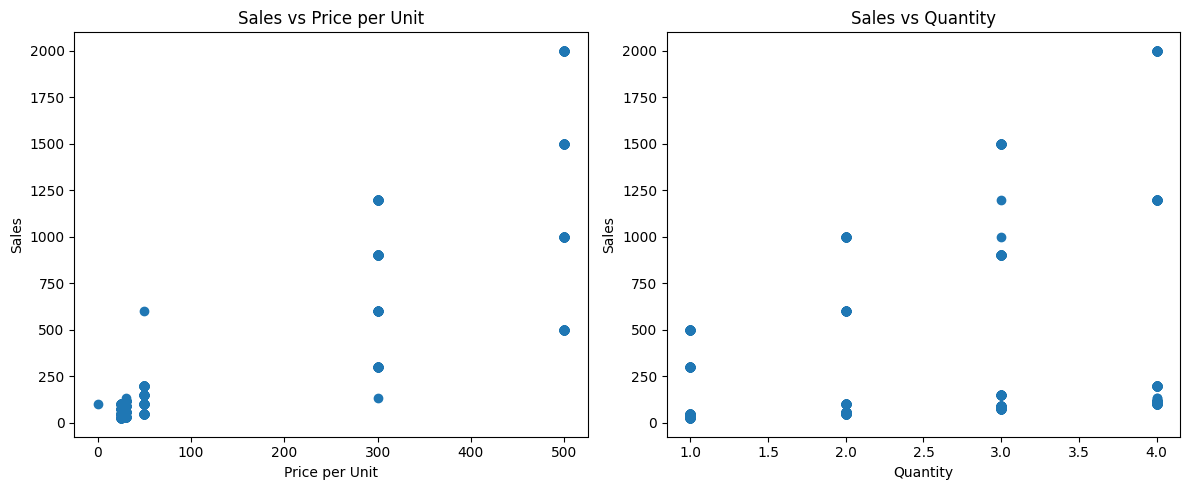

In [68]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Sales vs Price per Unit
axes[0].scatter(df["Price per Unit"], df["Sales"])
axes[0].set_title("Sales vs Price per Unit")
axes[0].set_xlabel("Price per Unit")
axes[0].set_ylabel("Sales")

# 2. Sales vs Quantity
axes[1].scatter(df["Quantity"], df["Sales"])
axes[1].set_title("Sales vs Quantity")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

In [69]:
#4.Which Month produce the highest sales?

In [70]:
df["Date"]=df["Date"].apply(pd.to_datetime)

In [71]:
df["Month"] = df["Date"].dt.month

In [72]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales,Outlier_Flag,Month
0,1,2023-11-24,CUST001,male,34,Beauty,3.0,50.0,150.0,False,11.0
1,2,2023-02-27,CUST002,female,26,Clothing,2.0,500.0,1000.0,False,2.0
2,3,2023-01-13,CUST003,male,50,Electronics,1.0,30.0,30.0,False,1.0
3,4,2023-05-21,CUST004,male,37,Clothing,1.0,500.0,500.0,False,5.0
4,5,2023-05-06,CUST005,male,30,Beauty,2.0,50.0,100.0,False,5.0


In [73]:
df.groupby('Month')["Sales"].count().reset_index()

,Month,Sales
0,1.0,77
1,2.0,85
2,3.0,73
3,4.0,86
4,5.0,104
5,6.0,77
6,7.0,72
7,8.0,94
8,9.0,65
9,10.0,96


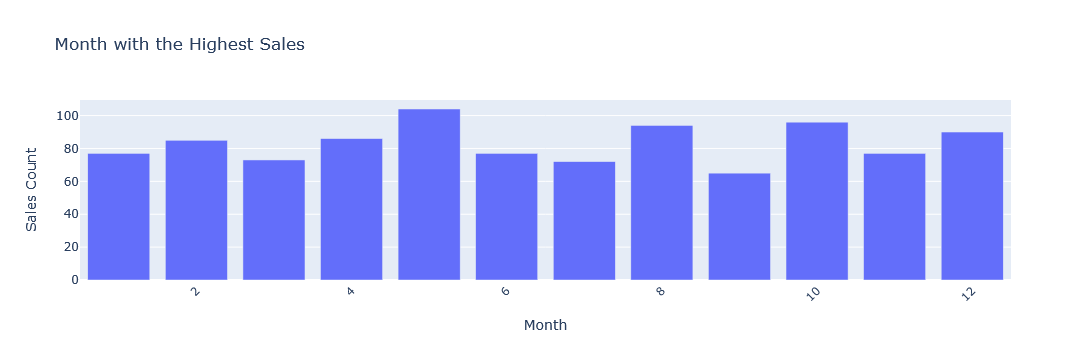

In [74]:
#Group data
month_sales = df.groupby("Month")["Sales"].count().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    month_sales,
    x="Month",
    y="Sales",
    title="Month with the Highest Sales",
    labels={"Month": "Month", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [75]:
df.groupby('Month')["Sales"].sum().reset_index()

,Month,Sales
0,1.0,34995.0
1,2.0,44060.0
2,3.0,28990.0
3,4.0,33870.0
4,5.0,53060.0
5,6.0,36715.0
6,7.0,35465.0
7,8.0,36960.0
8,9.0,22555.0
9,10.0,46580.0


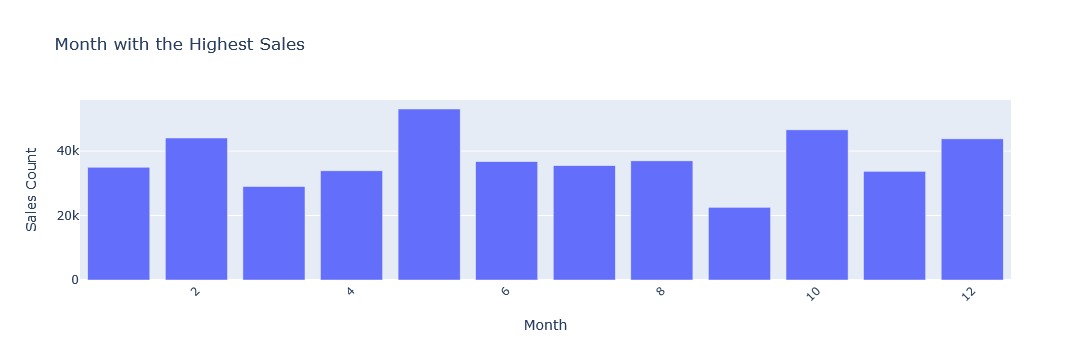

In [76]:
#Group data
month_sales = df.groupby("Month")["Sales"].sum().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    month_sales,
    x="Month",
    y="Sales",
    title="Month with the Highest Sales",
    labels={"Month": "Month", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

From the findings on our charts Month 5 which is May has the highest revenue

In [77]:
#5.Where should the company focus to increase revenue?

The company should focus on Electronics because it generates the highest revenue, indicating strong value per transaction. Clothing also presents a major growth opportunity due to its high sales volume and close revenue performance. Additionally, the company should analyze the success factors behind Month 5, which produced the highest revenue, and replicate those strategies during lower-performing months such as Month 9. Finally, improving product categorization will enhance reporting accuracy and business decision-making.”